**UID**: unique identifier ranging from 1 to 10000

**product ID**: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number

**type**: just the product type L, M or H from column 2

**air temperature [K]**: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K

**process temperature [K]**: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.

**rotational speed [rpm]**: calculated from a power of 2860 W, overlaid with a normally distributed noise

**torque [Nm]**: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.

**tool wear [min]**: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.

a **'machine failure'** label that indicates, whether the machine has failed in this particular datapoint for any of the following failure modes are true.

The machine failure consists of five independent failure modes-

**tool wear failure (TWF):** the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins (120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 51 times (randomly assigned).

**heat dissipation failure (HDF)**: heat dissipation causes a process failure, if the difference between air- and process temperature is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.

**power failure (PWF)**: the product of torque and rotational speed (in rad/s) equals the power required for the process. If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.

**overstrain failure (OSF)**: if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H), the process fails due to overstrain. This is true for 98 datapoints.

**random failures (RNF)**: each process has a chance of 0,1 % to fail regardless of its process parameters. This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in our dataset.

If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1. It is therefore not transparent to the machine learning method, which of the failure modes has caused the process to fail.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [ ]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [ ]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [ ]:
categorical_col = ["Type"]
numerical_col=[col for col in df.columns if col not in categorical_col]

print(categorical_col)
print(numerical_col)

['Type']
['UDI', 'Product ID', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


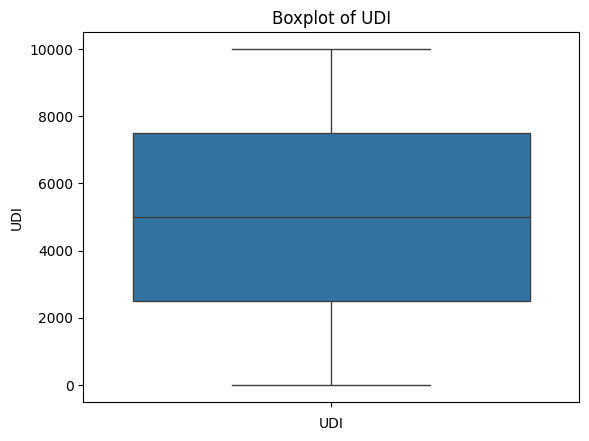

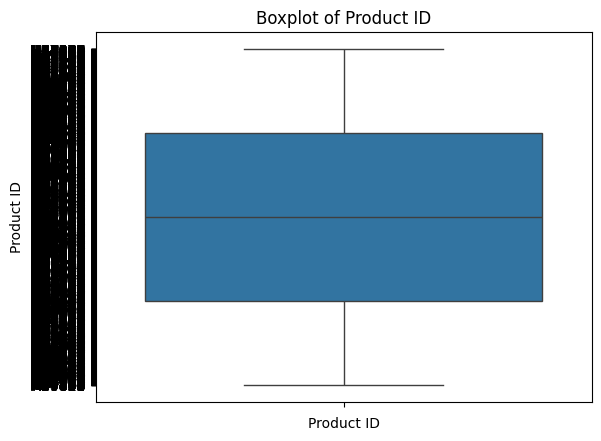

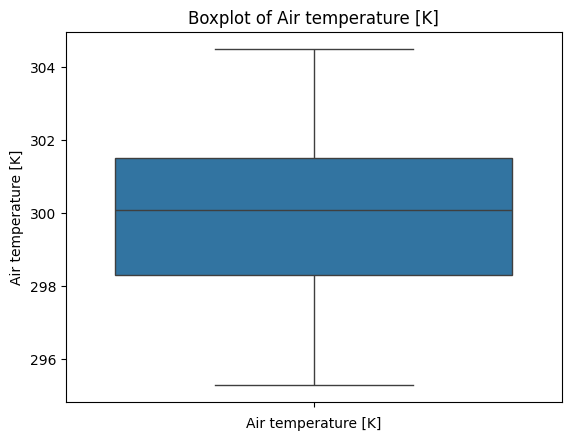

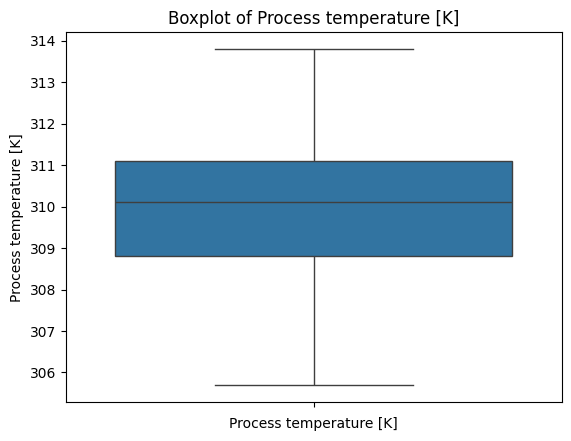

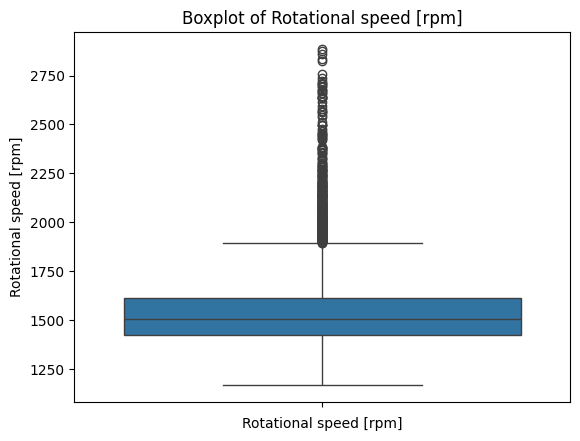

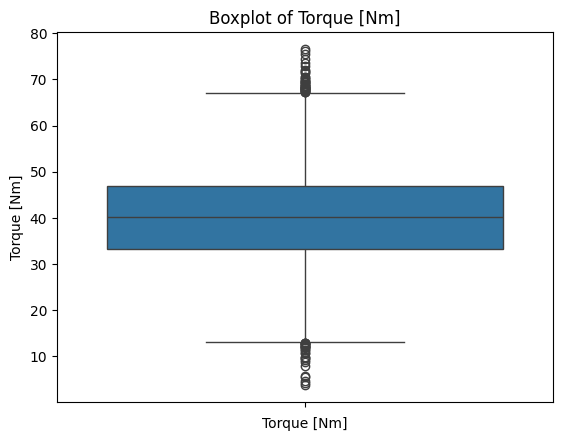

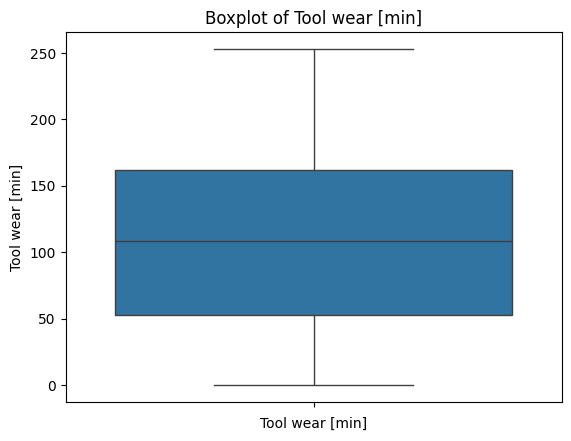

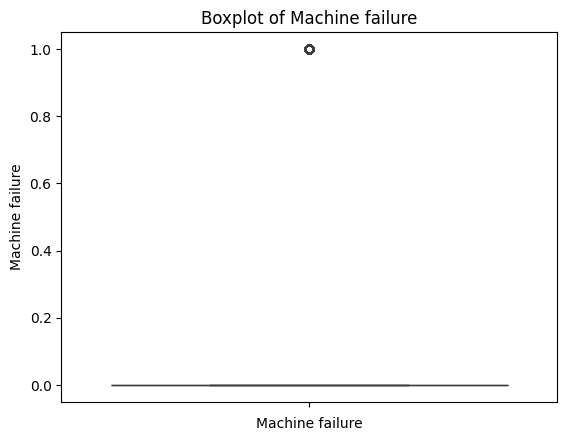

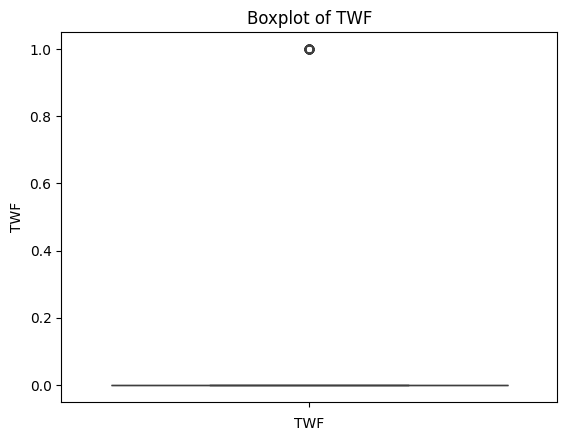

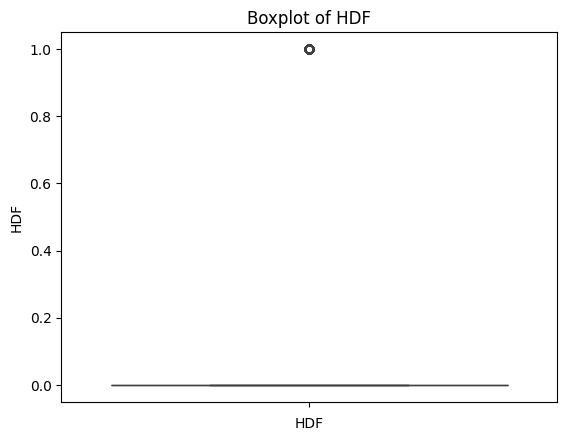

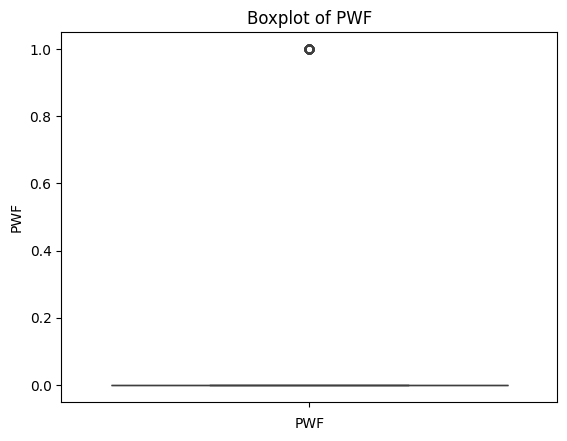

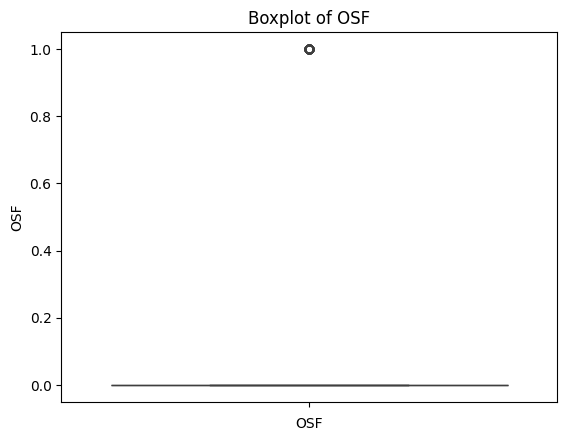

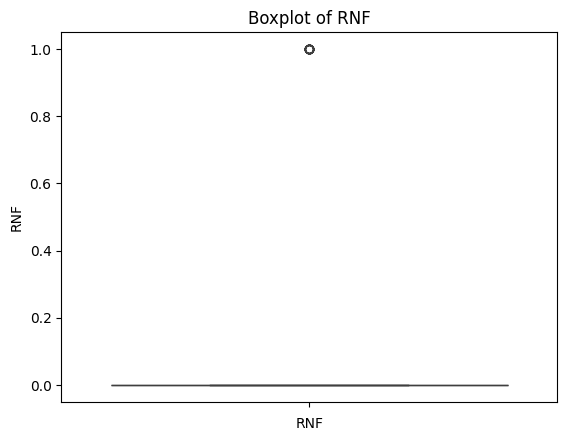


--- Outlier Analysis for 'Rotational speed [rpm]' and 'Torque [Nm]' ---

Column: Rotational speed [rpm]
  Q1: 1423.00, Q3: 1612.00, IQR: 189.00
  Lower Bound for Outliers: 1139.50
  Upper Bound for Outliers: 1895.50
  Number of outliers: 418

Column: Torque [Nm]
  Q1: 33.20, Q3: 46.80, IQR: 13.60
  Lower Bound for Outliers: 12.80
  Upper Bound for Outliers: 67.20
  Number of outliers: 69


In [ ]:
for var in numerical_col:
  sns.boxplot(y=df[var])
  plt.title(f"Boxplot of {var}")
  plt.xlabel(var)
  plt.show()

# Based on your observation, let's look at outliers in 'Rotational speed [rpm]' and 'Torque [Nm]'
print("\n--- Outlier Analysis for 'Rotational speed [rpm]' and 'Torque [Nm]' ---")

for col in ['Rotational speed [rpm]', 'Torque [Nm]']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound for Outliers: {lower_bound:.2f}")
    print(f"  Upper Bound for Outliers: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}")

In [ ]:
outlier_col = ['Rotational speed [rpm]', 'Torque [Nm]']
outlier_col

['Rotational speed [rpm]', 'Torque [Nm]']

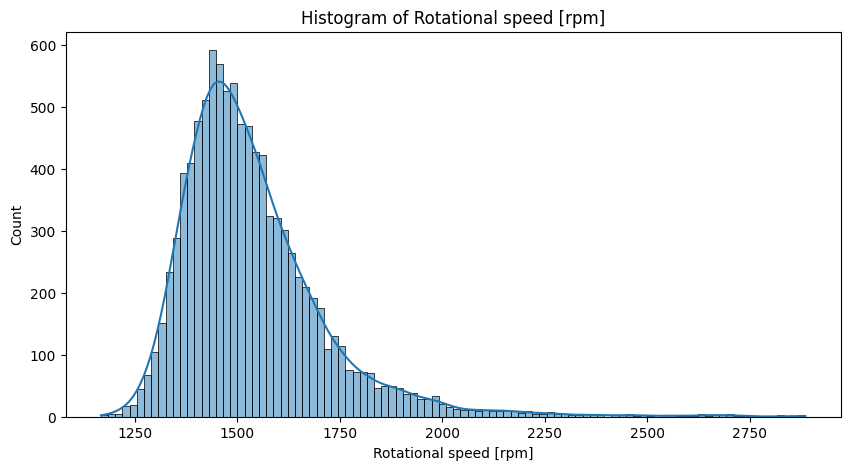

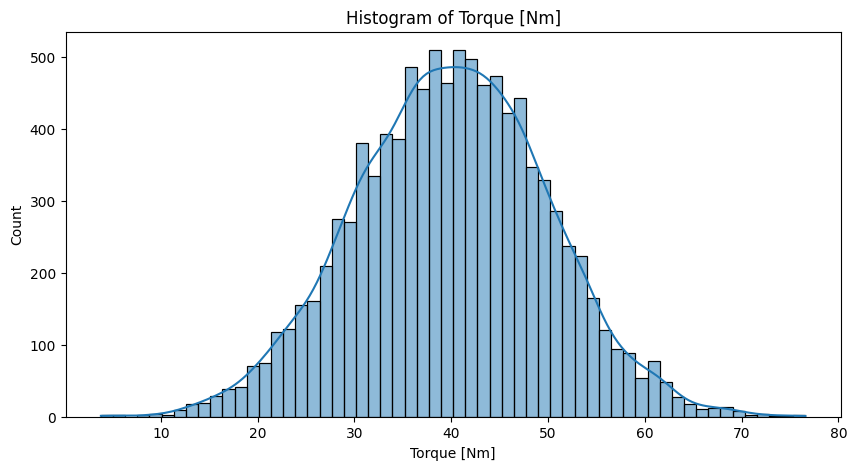

In [ ]:
for col in outlier_col:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col],kde=True)
  plt.title(f"Histogram of {col}")
  plt.xlabel(col)
  plt.show()

Torque is Normally Distributed

However rpm is **Right Skewed**, so we can apply **Log-Transformation**.

In [ ]:
df["log_rpm"] = np.log1p(df["Rotational speed [rpm]"])

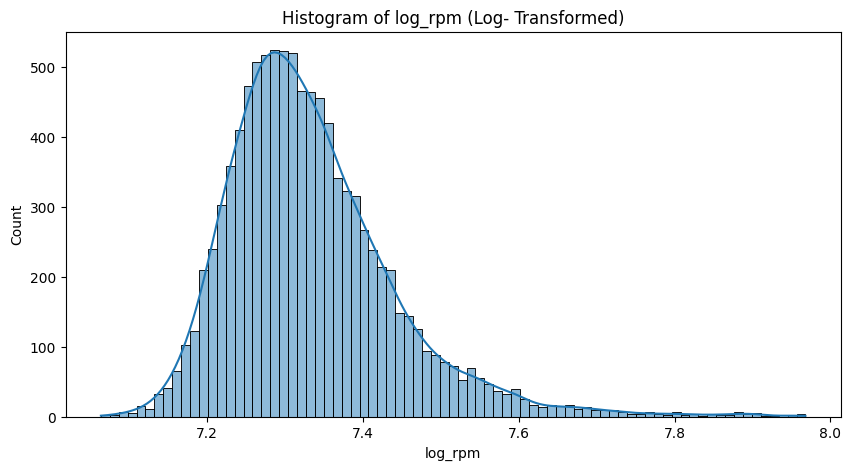

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["log_rpm"],kde=True)
plt.title(f"Histogram of log_rpm (Log- Transformed)")
plt.xlabel("log_rpm")
plt.show()

In [ ]:
from scipy.stats import boxcox
df['rpm_boxcox'], lambda_depth = boxcox(df['Rotational speed [rpm]'] + 1)

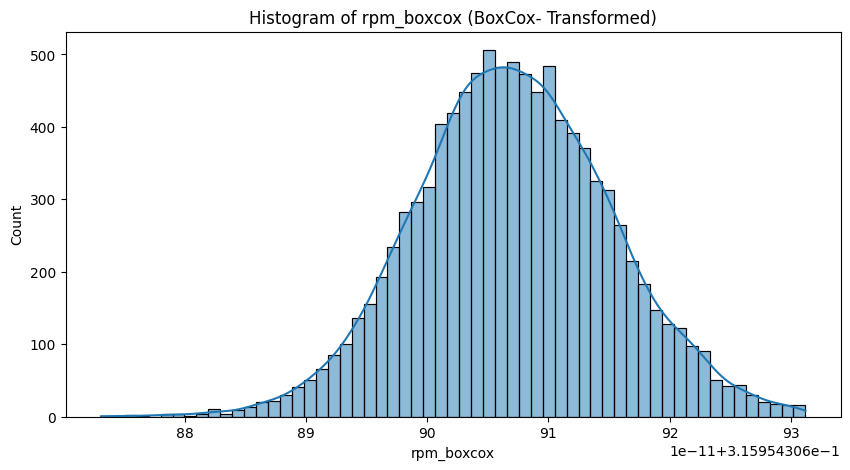

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["rpm_boxcox"],kde=True)
plt.title(f"Histogram of rpm_boxcox (BoxCox- Transformed)")
plt.xlabel("rpm_boxcox")
plt.show()

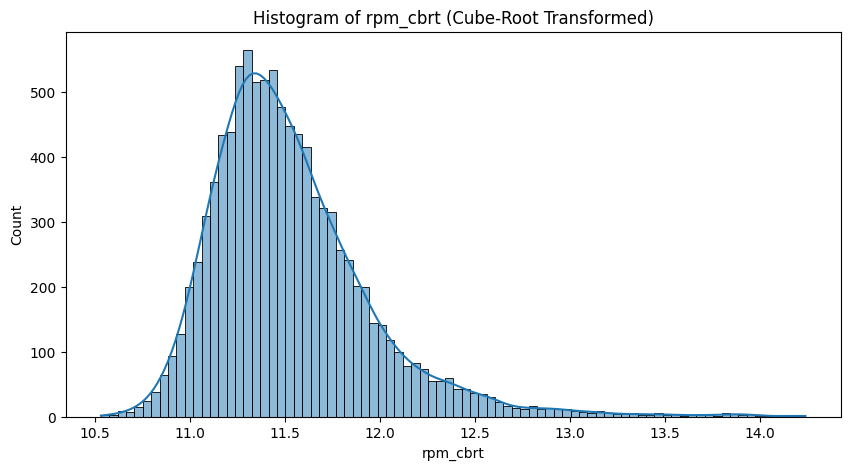

In [ ]:
df['rpm_cbrt'] = np.cbrt(df['Rotational speed [rpm]'])

plt.figure(figsize=(10,5))
sns.histplot(df["rpm_cbrt"], kde=True)
plt.title(f"Histogram of rpm_cbrt (Cube-Root Transformed)")
plt.xlabel("rpm_cbrt")
plt.show()

### Comparing Distributions: Original vs. Transformed 'Rotational speed [rpm]'

Let's visualize the original and transformed distributions to visually assess which one appears most normal.

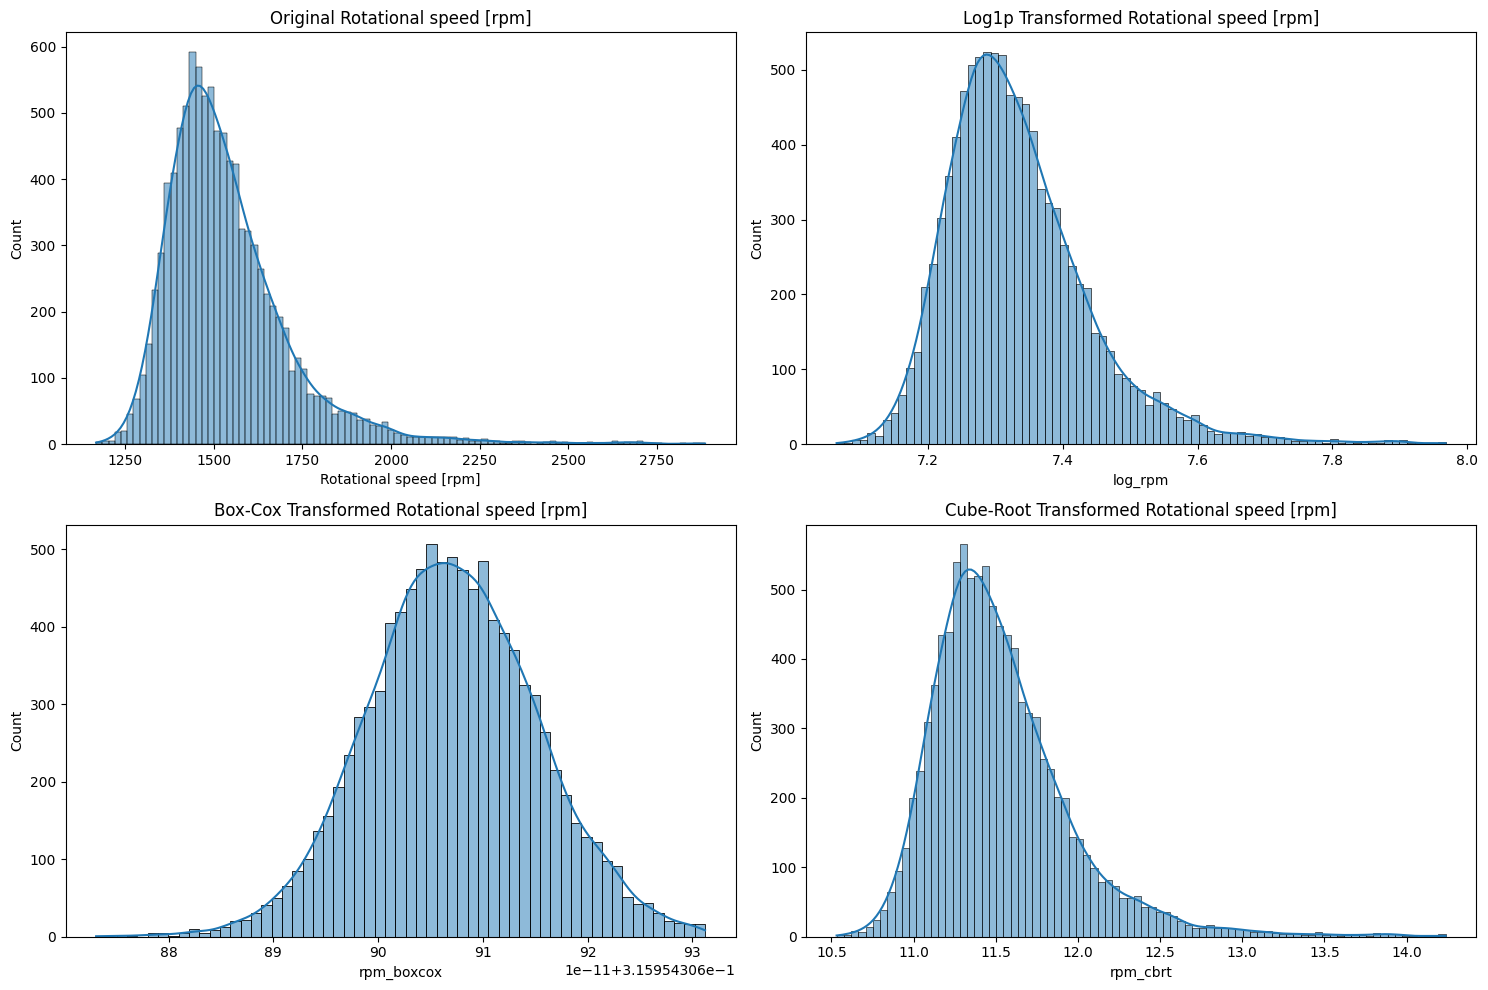

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['Rotational speed [rpm]'], kde=True)
plt.title('Original Rotational speed [rpm]')

plt.subplot(2, 2, 2)
sns.histplot(df['log_rpm'], kde=True)
plt.title('Log1p Transformed Rotational speed [rpm]')

plt.subplot(2, 2, 3)
sns.histplot(df['rpm_boxcox'], kde=True)
plt.title('Box-Cox Transformed Rotational speed [rpm]')

plt.subplot(2, 2, 4)
sns.histplot(df['rpm_cbrt'], kde=True)
plt.title('Cube-Root Transformed Rotational speed [rpm]')

plt.tight_layout()
plt.show()

### Shapiro-Wilk Test for Normality

To quantitatively assess normality, we can use the Shapiro-Wilk test. A higher p-value (typically greater than 0.05) suggests that we cannot reject the null hypothesis that the data is normally distributed.

In [ ]:
from scipy.stats import shapiro

columns_to_test = {
    'Original Rotational speed [rpm]': df['Rotational speed [rpm]'],
    'Log1p Transformed': df['log_rpm'],
    'Box-Cox Transformed': df['rpm_boxcox'],
    'Cube-Root Transformed': df['rpm_cbrt']
}

print("Shapiro-Wilk Test Results:")
for name, data in columns_to_test.items():
    stat, p = shapiro(data)
    print(f"  {name}: Statistics={stat:.3f}, p={p:.3g}")
    if p > 0.05:
        print(f"    (Fail to reject H0: Appears Gaussian)")
    else:
        print(f"    (Reject H0: Does not appear Gaussian)")

Shapiro-Wilk Test Results:
  Original Rotational speed [rpm]: Statistics=0.865, p=2.1e-68
    (Reject H0: Does not appear Gaussian)
  Log1p Transformed: Statistics=0.927, p=2.21e-56
    (Reject H0: Does not appear Gaussian)
  Box-Cox Transformed: Statistics=0.999, p=7.6e-05
    (Reject H0: Does not appear Gaussian)
  Cube-Root Transformed: Statistics=0.909, p=1.39e-60
    (Reject H0: Does not appear Gaussian)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


Based on the visual comparison of the histograms and the p-values from the Shapiro-Wilk tests, you can determine which transformation resulted in a distribution closest to normal. Generally, a higher p-value indicates a distribution that is more likely to be normal. Look for the transformation with the highest p-value if none are above the 0.05 significance level, or the one that passes the normality test (p > 0.05).

In [ ]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,log_rpm,rpm_boxcox,rpm_cbrt
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,1.000000e+04,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,7.333330,3.159543e-01,11.529127
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,0.107449,8.083742e-12,0.423436
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.063904,3.159543e-01,10.531275
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.261225,3.159543e-01,11.247819
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.315884,3.159543e-01,11.454769
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.385851,3.159543e-01,11.725238
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,7.967973,3.159543e-01,14.237447


In [ ]:
df.shape

(10000, 17)

**BOXCOX gave result much closer to Normal distribution, thus we will keep it.**

In [ ]:
df.drop("log_rpm", axis=1, inplace=True)
df.drop("rpm_cbrt", axis=1, inplace=True)
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,rpm_boxcox
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,1.000000e+04
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,3.159543e-01
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,8.083742e-12
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,3.159543e-01


In [ ]:
df.shape

(10000, 15)

In [ ]:
transform_outlier_col = ['rpm_boxcox', 'Torque [Nm]']
transform_outlier_col

['rpm_boxcox', 'Torque [Nm]']

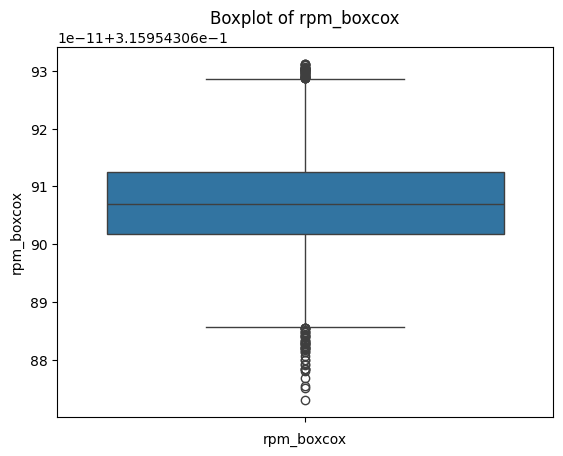

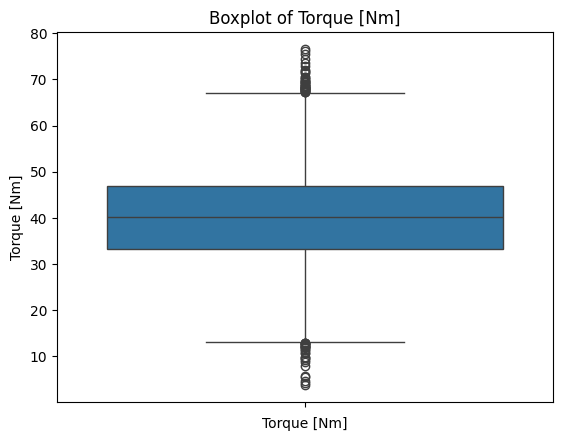

In [ ]:
for var in transform_outlier_col:
  sns.boxplot(y=df[var])
  plt.title(f"Boxplot of {var}")
  plt.xlabel(var)
  plt.show()

In [ ]:
for col in transform_outlier_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound for Outliers: {lower_bound:.2f}")
    print(f"  Upper Bound for Outliers: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}")


Column: rpm_boxcox
  Q1: 0.32, Q3: 0.32, IQR: 0.00
  Lower Bound for Outliers: 0.32
  Upper Bound for Outliers: 0.32
  Number of outliers: 90

Column: Torque [Nm]
  Q1: 33.20, Q3: 46.80, IQR: 13.60
  Lower Bound for Outliers: 12.80
  Upper Bound for Outliers: 67.20
  Number of outliers: 69


**In Rotational speed [rpm], Outliers reduced from 418 to 90 !**

In [ ]:
df.drop("Rotational speed [rpm]", axis=1, inplace=True)
df.describe()

,UDI,Air temperature [K],Process temperature [K],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,rpm_boxcox
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,1.000000e+04
mean,5000.50000,300.004930,310.005560,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,3.159543e-01
std,2886.89568,2.000259,1.483734,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,8.083742e-12
min,1.00000,295.300000,305.700000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
25%,2500.75000,298.300000,308.800000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
50%,5000.50000,300.100000,310.100000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
75%,7500.25000,301.500000,311.100000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,3.159543e-01
max,10000.00000,304.500000,313.800000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,3.159543e-01


In [ ]:
categorical_col = ["Type", "Product ID"]
numerical_col=[col for col in df.columns if col not in categorical_col]

print(categorical_col)
print(numerical_col)

['Type', 'Product ID']
['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'rpm_boxcox']


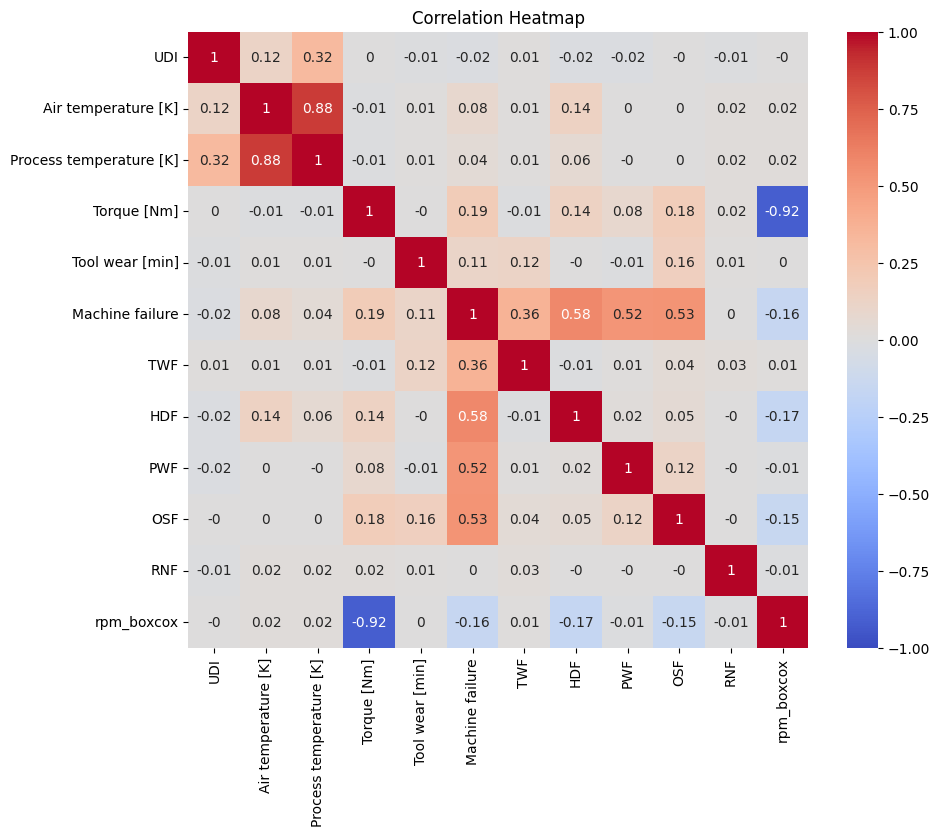

In [ ]:
corr = df[numerical_col].corr().round(2)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

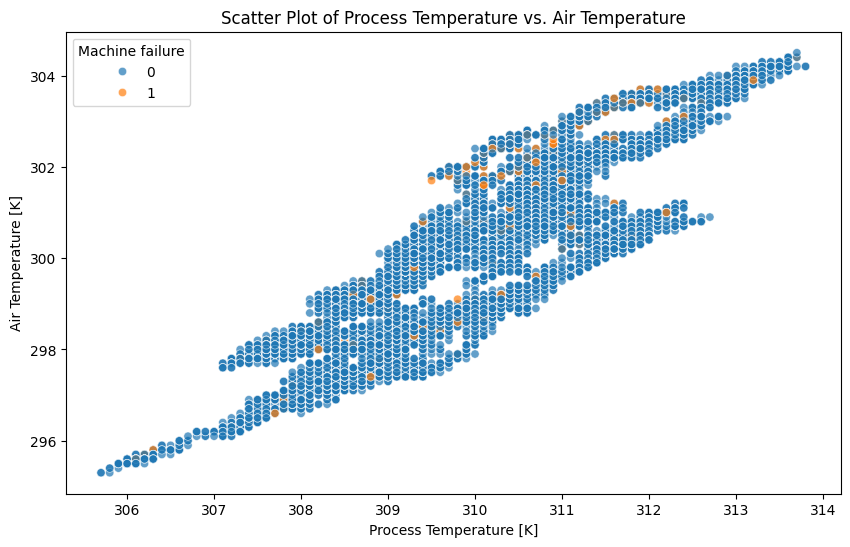

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Process temperature [K]", y="Air temperature [K]", hue="Machine failure", alpha=0.7, data=df)
plt.title("Scatter Plot of Process Temperature vs. Air Temperature")
plt.xlabel("Process Temperature [K]")
plt.ylabel("Air Temperature [K]")
plt.show()

From the Scatter Plot of Process Temperature vs. Air Temperature,

We can say that at Air_Temp >= 302 & Process_Temp >=310

There is a chance of Machine Failure!!

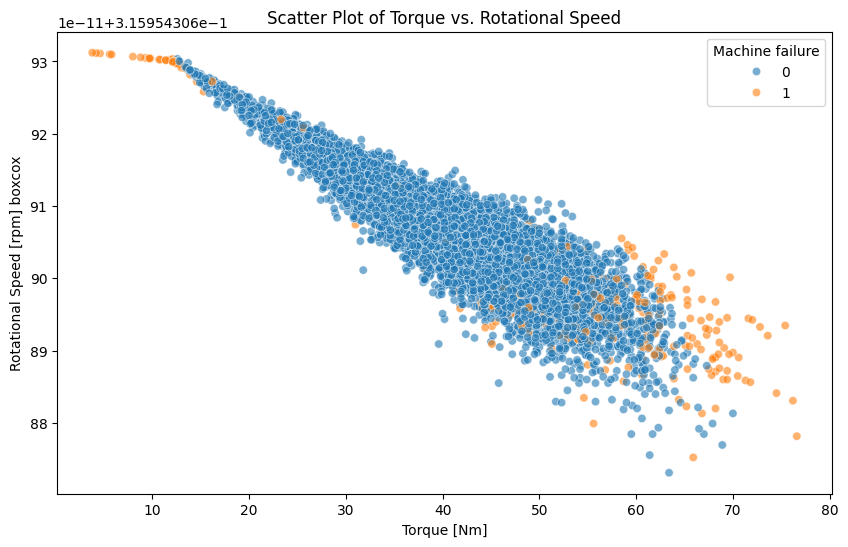

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Torque [Nm]", y="rpm_boxcox", hue="Machine failure", alpha=0.6, data=df)
plt.title("Scatter Plot of Torque vs. Rotational Speed")
plt.xlabel("Torque [Nm]")
plt.ylabel("Rotational Speed [rpm] boxcox")
plt.show()

From the Scatter Plot of Torque vs. Rotational Speed (rpm)

We can tell that, if Rotational Speed is High & Torque is low -> Chances of Machine Failure increases!

similarly, if Rotational Speed is Low & Torque is High -> Chances of Machine Failure also increases!

**Feature Engineering**

In [ ]:
df["power"] = df["Torque [Nm]"] * df["rpm_boxcox"]

df["temp_diff "] = df["Process temperature [K]"] - df["Air temperature [K]"]

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,rpm_boxcox,power,temp_diff
0,1,M14860,M,298.1,308.6,42.8,0,0,0,0,0,0,0,0.315954,13.522844,10.5
1,2,L47181,L,298.2,308.7,46.3,3,0,0,0,0,0,0,0.315954,14.628684,10.5
2,3,L47182,L,298.1,308.5,49.4,5,0,0,0,0,0,0,0.315954,15.608143,10.4
3,4,L47183,L,298.2,308.6,39.5,7,0,0,0,0,0,0,0.315954,12.480195,10.4
4,5,L47184,L,298.2,308.7,40.0,9,0,0,0,0,0,0,0.315954,12.638172,10.5


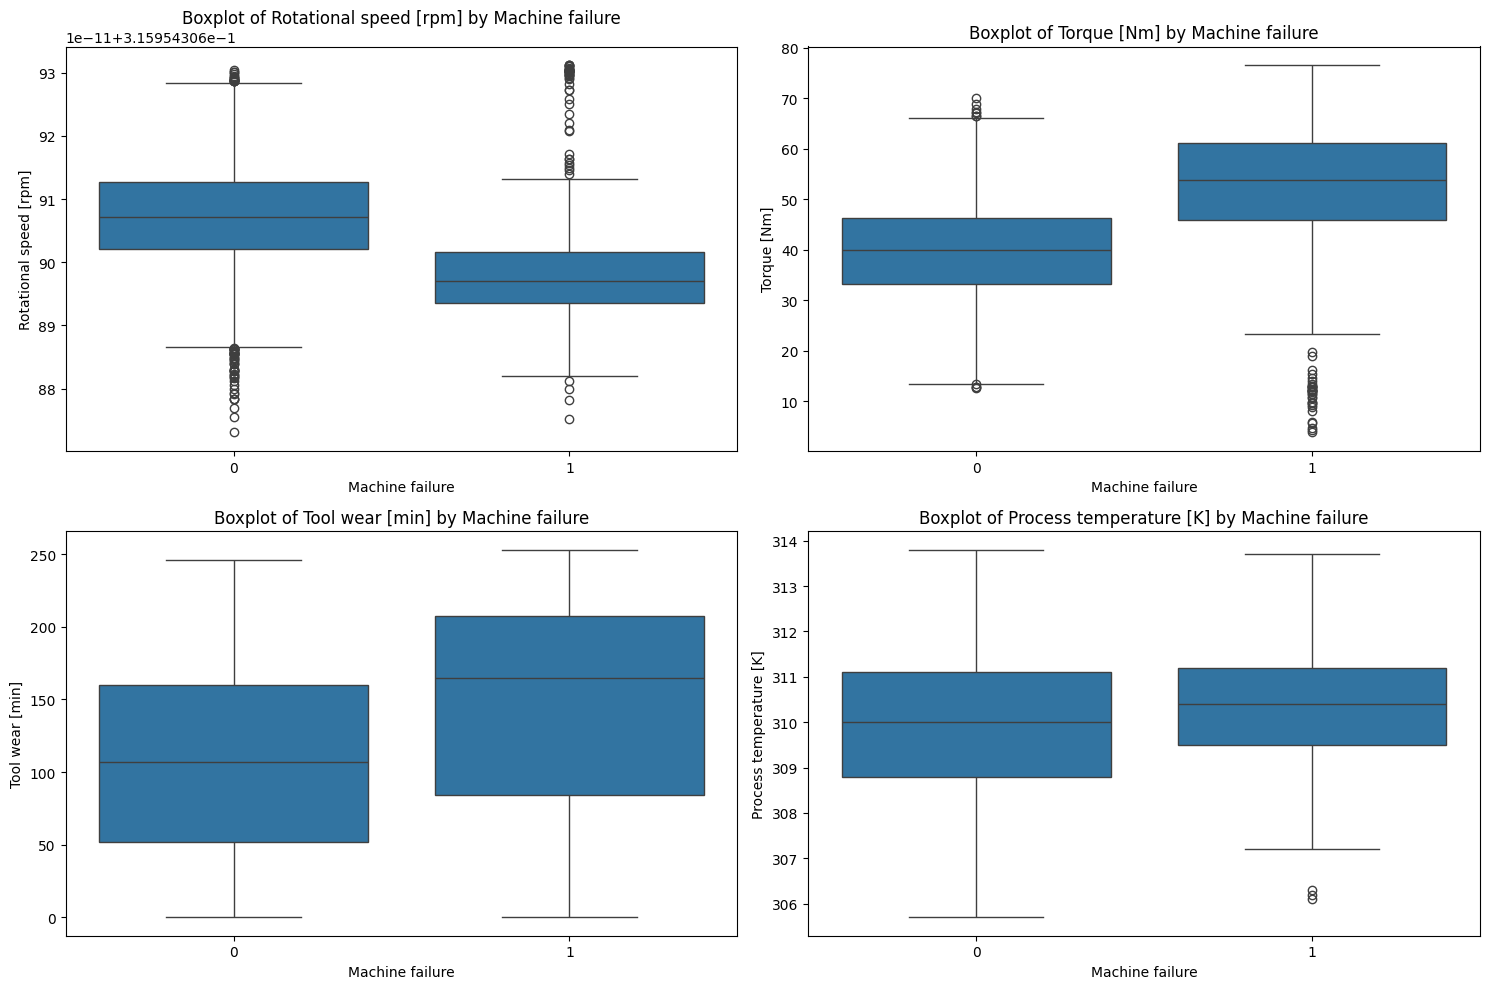

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.boxplot(x='Machine failure', y='rpm_boxcox', data=df)
plt.title('Boxplot of Rotational speed [rpm] by Machine failure')
plt.xlabel('Machine failure')
plt.ylabel('Rotational speed [rpm]')

plt.subplot(2, 2, 2)
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.title('Boxplot of Torque [Nm] by Machine failure')
plt.xlabel('Machine failure')
plt.ylabel('Torque [Nm]')

plt.subplot(2, 2, 3)
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)
plt.title('Boxplot of Tool wear [min] by Machine failure')
plt.xlabel('Machine failure')
plt.ylabel('Tool wear [min]')

plt.subplot(2, 2, 4)
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df)
plt.title('Boxplot of Process temperature [K] by Machine failure')
plt.xlabel('Machine failure')
plt.ylabel('Process temperature [K]')

plt.tight_layout()
plt.show()

1. Rotational Speed [rpm]

*   Failure machines have slightly LOWER RPM.
*   Insight: -Lower RPM conditions may be associated with failures.

  **Business Meaning-**
Machine instability/load issues could happen at lower rotational speeds.


2. Torque [Nm]

* Failure cases have MUCH HIGHER torque.

* Insight: -High torque strongly contributes to machine failure.

**Business Meaning-**
Higher mechanical load increases failure risk.

3. Tool Wear [min]

* Failure machines have HIGHER tool wear.

* Insight: -Older/worn tools fail more often.

**Business Meaning-**
Maintenance should happen before wear becomes excessive.

4. Process Temperature [K]

* Only slight increase in failure cases.

* Insight: -Temperature has weaker influence compared to torque/wear.

**Business Meaning-**
Temperature alone may not explain failures strongly.

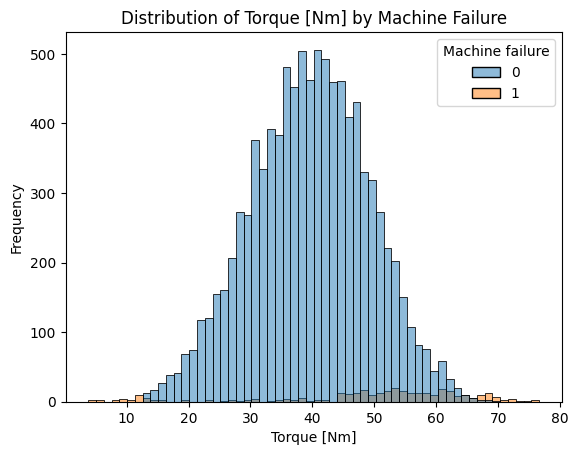

In [ ]:
sns.histplot(data=df, x='Torque [Nm]', hue='Machine failure')
plt.title('Distribution of Torque [Nm] by Machine Failure')
plt.xlabel('Torque [Nm]')
plt.ylabel('Frequency')
plt.show()

*Higher torque increases machine stress/load.*

**Business Insight:**

Machines operating at very high torque: -

* are riskier
* may require monitoring
* may need earlier maintenance

**Business KPI Analytics**

In [ ]:
# 1. Total Machines
total_machines = len(df)

print(f"Total Machines: {total_machines}")

# 2. Total Failures

total_failures = df['Machine failure'].sum()

print(f"Total Failures: {total_failures}")

# 3. Failure Rate
failure_rate = (total_failures / total_machines) * 100

print(f"Failure Rate: {failure_rate:.2f}%")

# 4. Average Tool Wear Before Failure
avg_tool_wear = df[df['Machine failure'] == 1]['Tool wear [min]'].mean()

print(f"Average Tool Wear Before Failure: {avg_tool_wear:.2f} minutes")

# 5. Average Torque During Failure
avg_torque_during_failure = df[df['Machine failure'] == 1]['Torque [Nm]'].mean()

print(f"Average Torque During Failure: {avg_torque_during_failure:.2f} Nm")

# 6. High Risk Machines
# Condition:
# High Torque + High Tool Wear
high_risk = df[
    (df['Torque [Nm]'] > 55) &
    (df['Tool wear [min]'] > 150)
]

print(f"High Risk Machines Count: {len(high_risk)}")

high_risk.head()

Total Machines: 10000
Total Failures: 339
Failure Rate: 3.39%
Average Tool Wear Before Failure: 143.78 minutes
Average Torque During Failure: 50.17 Nm
High Risk Machines Count: 175


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,rpm_boxcox,power,temp_diff
69,70,L47249,L,298.9,309.0,65.7,191,1,0,0,1,1,0,0.315954,20.758198,10.1
139,140,L47319,L,298.8,308.6,55.8,155,0,0,0,0,0,0,0.315954,17.630250,9.8
160,161,L47340,L,298.4,308.2,60.7,216,1,0,0,0,1,0,0.315954,19.178426,9.8
242,243,L47422,L,298.0,308.2,58.8,202,1,0,0,0,1,0,0.315954,18.578113,10.2
248,249,L47428,L,298.0,308.3,56.8,216,1,0,0,0,1,0,0.315954,17.946205,10.3


Failure Type Counts:
TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


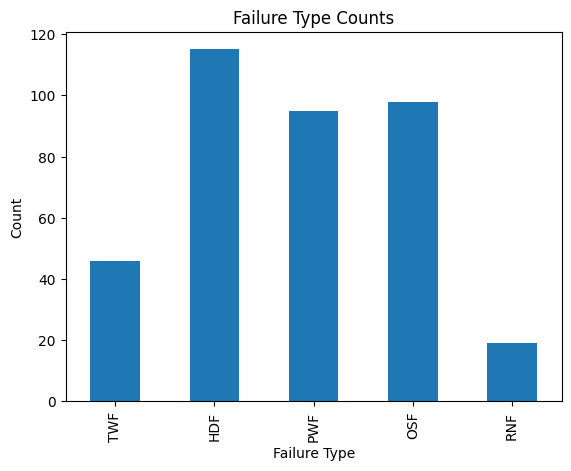


Machines in Dangerous Torque Zone: 2.36%


In [ ]:
# 7. Failure Type Counts
failure_type_counts = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()

print("Failure Type Counts:")
print(failure_type_counts)

# 8. Failure Type Visualization
failure_type_counts.plot(kind='bar')
plt.title('Failure Type Counts')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.show()

# 9. Machines Operating in Dangerous Torque Zone
danger_zone = df[df['Torque [Nm]'] > 60]

danger_percentage = (len(danger_zone) / len(df)) * 100

print(f"\nMachines in Dangerous Torque Zone: {danger_percentage:.2f}%")

In [ ]:
# 10. KPI Summary Table
# ==============================

kpi_summary = {
    'Total Machines': total_machines,
    'Total Failures': total_failures,
    'Failure Rate (%)': round(failure_rate, 2),
    'Avg Tool Wear Before Failure': round(avg_tool_wear, 2),
    'Avg Torque During Failure': round(avg_torque_during_failure, 2),
    'High Risk Machines counts': len(high_risk),
    'Machines in Dangerous Torque Zone': round(danger_percentage, 2)
}

kpi_df = pd.DataFrame(kpi_summary.items(), columns=['KPI', 'Value'])

kpi_df

,KPI,Value
0,Total Machines,10000.00
1,Total Failures,339.00
2,Failure Rate (%),3.39
3,Avg Tool Wear Before Failure,143.78
4,Avg Torque During Failure,50.17
5,High Risk Machines counts,175.00
6,Machines in Dangerous Torque Zone,2.36


**Saving the Normalized Data**

In [ ]:
df.to_csv("predictive_maintenance_cleaned.csv", index=False)

**Model Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df.drop(['Machine failure', 'UDI', 'Product ID','TWF','HDF','PWF','OSF','RNF'], axis=1)
y = df["Machine failure"]

In [ ]:
X = pd.get_dummies(X, columns=['Type'], drop_first=True)
X.head()

,Air temperature [K],Process temperature [K],Torque [Nm],Tool wear [min],rpm_boxcox,power,temp_diff,Type_L,Type_M
0,298.1,308.6,42.8,0,0.315954,13.522844,10.5,False,True
1,298.2,308.7,46.3,3,0.315954,14.628684,10.5,True,False
2,298.1,308.5,49.4,5,0.315954,15.608143,10.4,True,False
3,298.2,308.6,39.5,7,0.315954,12.480195,10.4,True,False
4,298.2,308.7,40.0,9,0.315954,12.638172,10.5,True,False


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
log_reg = LogisticRegression(max_iter=500, class_weight="balanced")
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500)

In [ ]:
y_pred = log_reg.predict(X_test)

In [ ]:
print("Accuracy:" , accuracy_score(y_test, y_pred))

Accuracy: 0.7495


In [ ]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.75      0.85      1939
           1       0.08      0.74      0.15        61

    accuracy                           0.75      2000
   macro avg       0.54      0.74      0.50      2000
weighted avg       0.96      0.75      0.83      2000


Confusion Matrix:

[[1454  485]
 [  16   45]]


# Conclusion

- Successfully performed end-to-end predictive maintenance analytics
- Conducted detailed EDA and failure pattern analysis
- Engineered meaningful operational features
- Applied Logistic Regression for machine failure prediction
- Handled class imbalance using balanced class weights
- Evaluated model performance using classification metrics and confusion matrix
- Derived actionable maintenance and operational insights from sensor data

---

# Key Takeaways

- High torque and tool wear strongly contribute to machine failures
- Predictive analytics can help reduce operational downtime
- Business intelligence tools improve monitoring and decision-making
- Combining analytics, visualization, and ML creates practical industrial solutions